# Bài tập thực hành tuần 3
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import sys
from time import perf_counter
from math import log2


# Từ Python 3.11+, giới hạn số chữ số cho các phép chuyển đổi int <-> str bị giới hạn ở 4300.
# Cần cấu hình nới lỏng giới hạn này để chạy được N lớn (ví dụ N = 2^12 = 4096).
sys.set_int_max_str_digits(1000000)
sys.setrecursionlimit(10000)

### Bài tập 1:
**Câu hỏi**:

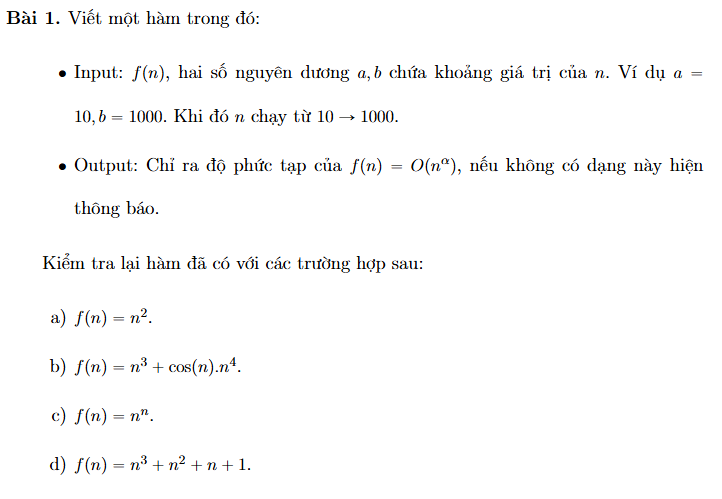

Note: Output của bài 1 yêu cầu là CHỈ RA độ phức tạp của f(n) = O(n^a), nếu không thì hiện thông báo. Vì vậy, ta có thể chỉ cần làm thuật toán để kiểm tra điều đó.

In [14]:
def findN_Alpha(func):
    arr = np.linspace(10, 1000)
    vals = np.abs(func(arr))
    
    alphas = np.log(vals) / np.log(arr)
    max_alpha = np.nanmax(alphas)
    
    if max_alpha == np.inf:
        print(f' O(n^a) not exist')
        return None
    else:
        print(f' f ~= O(n^{round(max_alpha)}) ')
        return max_alpha
    
def func_a(n): 
    return n**2
def func_b(n): 
    return n**3 + np.cos(n) * n**4
def func_c(n): 
    return n**n
def func_d(n): 
    return n**3 + n**2 + n + 1

print("a)", end="")
findN_Alpha(func_a)
print("b)", end="")
findN_Alpha(func_b)
print("c)", end="")
findN_Alpha(func_c)
print("d)", end="")
findN_Alpha(func_d)

a) f ~= O(n^2) 
b) f ~= O(n^4) 
c) O(n^a) not exist
d) f ~= O(n^3) 


C:\Users\lenovo\AppData\Local\Temp\ipykernel_12116\4176933670.py:20: RuntimeWarning: overflow encountered in power
  return n**n


np.float64(3.0457140589408676)

```python
def findN_Alpha(func):
    arr = np.linspace(10, 1000)
    vals = np.abs(func(arr))
    
    alphas = np.log(vals) / np.log(arr)
    max_alpha = np.nanmax(alphas)
    
    if max_alpha == np.inf:
        print(f' O(n^a) not exist')
        return None
    else:
        print(f' f ~= O(n^{round(max_alpha)}) ')
        return max_alpha
```


Đầu tiên, ta tạo một mảng `arr` từ 10 đến 1000 để kiểm tra giá trị của hàm `func` tại các điểm này. Sau đó, ta tính giá trị tuyệt đối của `func(arr)` và lưu vào `vals`.
``` python
arr = np.linspace(10, 1000)
vals = np.abs(func(arr))
```
Tiếp theo, ta tính giá trị của `alpha` bằng cách lấy logarit của `vals` chia cho logarit của `arr` theo như trong phần hướng dẫn. Điều này giúp ta xác định độ phức tạp của hàm `func`.
``` python
alphas = np.log(vals) / np.log(arr)
```

Sau đó, ta tìm giá trị lớn nhất của `alpha` bằng cách sử dụng `np.nanmax()`, vì có thể có giá trị NaN nếu `vals` chứa giá trị âm hoặc bằng 0.
``` python
max_alpha = np.nanmax(alphas)
```

Cuối cùng, ta kiểm tra nếu `max_alpha` là vô hạn (`np.inf`), điều đó có nghĩa là hàm `func` không có độ phức tạp O(n^a) nào tồn tại. Nếu không, ta in ra độ phức tạp gần đúng của hàm `func`.
``` python
if max_alpha == np.inf:
    print(f' O(n^a) not exist')
    return None
else:
    print(f' f ~= O(n^{round(max_alpha)}) ')
    return max_alpha
```

Kết quả thu được là: 

Câu a: f(n) = O(n^2) <br>
Câu b: f(n) = O(n^4) <br>
Câu c: Không tìm được <br>
Câu d: f(n) = O(n^3) <br>

Nhưng nếu ta muốn tìm các hệ số a0, a1, a2,... thì ta có thể sử dụng phương pháp hồi quy tuyến tính để tìm các hệ số này. Dưới đây là một ví dụ về cách thực hiện điều đó:



In [15]:
import math
import numpy as np

def estimate_complexity(f, a, b):
    n_vals = []
    fn_vals = []
    log_n = []
    log_fn = []
    
    # BƯỚC 1: Lấy dữ liệu và chuyển sang dạng Logarit
    for n in range(a, b + 1):
        
            val = f(n)
            abs_val = abs(val) # Xét trị tuyệt đối cho độ lớn của hàm
            
            if abs_val > 0:
                # Xử lý các số cực lớn (vd n^n) để tránh lỗi tràn bộ nhớ (Overflow)
                if isinstance(abs_val, int) and abs_val > 1e250:
                    l_fn = abs_val.bit_length() * math.log(2)
                else:
                    l_fn = math.log(abs_val)
                    
                n_vals.append(n)
                fn_vals.append(val)
                log_n.append(math.log(n))
                log_fn.append(l_fn)


    if len(n_vals) < 2:
        print("giá trị n quá nhỏ hoặc hàm trả về giá trị không hợp lệ để ước lượng độ phức tạp.")
        return

    # Lọc đường bao trên (Upper Envelope) để tìm xu hướng thật sự
    # Kỹ thuật này giúp loại bỏ nhiễu khi hàm dao động lên xuống do cos(n)
    env_log_n, env_log_fn = [], []
    max_val = -float('inf')
    for ln, lfn in zip(log_n, log_fn):
        if lfn >= max_val:
            max_val = lfn
            env_log_n.append(ln)
            env_log_fn.append(lfn)

    # Chia đôi dữ liệu bao trên để kiểm tra xem hệ số góc có ổn định không
    # Nếu hệ số góc tăng vọt -> Hàm tăng phi đa thức (như hàm mũ n^n)
    mid = len(env_log_n) // 2
    if mid >= 2:
        slope1 = np.polyfit(env_log_n[:mid], env_log_fn[:mid], 1)[0]
        slope2 = np.polyfit(env_log_n[mid:], env_log_fn[mid:], 1)[0]
        if slope2 - slope1 > 0.5:
            print("Ko có dạng O(n^a)")
            return

    # Tính độ dốc trung bình của toàn bộ đường bao trên
    overall_slope = np.polyfit(env_log_n, env_log_fn, 1)[0]
    alpha = int(round(overall_slope))

    if alpha == 0:
        print("f(n) ~= O(1)")
    elif alpha == 1:
        print("f(n) ~= O(n)")
    else:
        print(f"f(n) ~= O(n^{alpha})")

    # BƯỚC 2: Thế f(n) và n để giải hệ phương trình tìm a_0, a_1,..., a_alpha
        # np.polyfit(X, Y, deg) trả về hệ số đa thức theo thứ tự: [a_alpha, ..., a_1, a_0]
        coeffs = np.polyfit(n_vals, fn_vals, alpha)
        
        # Đảo ngược mảng để in đúng thứ tự yêu cầu của đề: a_0, a_1, ..., a_alpha
        coeffs_reversed = coeffs[::-1]
        
        # Làm tròn hệ số để hiển thị sạch sẽ (khử sai số dấu phẩy động 0.0000001)
        coeffs_rounded = [round(c, 4) for c in coeffs_reversed]
        
        print(" => Các hệ số [a_0, a_1, ..., a_alpha]:")
        str_coeffs = [f"a_{i} = {c}" for i, c in enumerate(coeffs_rounded)]
        print("    " + ", ".join(str_coeffs))
        
        # In ra dạng đa thức trực quan
        poly_terms = []
        for i, c in enumerate(coeffs_rounded):
            if c != 0:
                if i == 0: poly_terms.append(f"{c}")
                elif i == 1: poly_terms.append(f"{c}n")
                else: poly_terms.append(f"{c}n^{i}")
        
        poly_str = " + ".join(poly_terms).replace("+ -", "- ")
        print(f" => Hàm xấp xỉ: f(n) ≈ {poly_str}")

# ==========================================
# KIỂM TRA CÁC TRƯỜNG HỢP (TEST CASES)
# ==========================================
def func_a(n): return n**2
def func_b(n): return n**3 + math.cos(n) * (n**4)
def func_c(n): return n**n
def func_d(n): return n**3 + n**2 + n + 1

if __name__ == "__main__":
    a, b = 10, 1000
    print("a) f(n) = n^2")
    estimate_complexity(func_a, a, b)
    
    print("b) f(n) = n^3 + cos(n).n^4")
    estimate_complexity(func_b, a, b)
    
    print("c) f(n) = n^n")
    estimate_complexity(func_c, a, b)
    
    print("d) f(n) = n^3 + n^2 + n + 1")
    estimate_complexity(func_d, a, b)

a) f(n) = n^2
f(n) ~= O(n^2)
 => Các hệ số [a_0, a_1, ..., a_alpha]:
    a_0 = -0.0, a_1 = 0.0, a_2 = 1.0
 => Hàm xấp xỉ: f(n) ≈ 1.0n^2
b) f(n) = n^3 + cos(n).n^4
f(n) ~= O(n^4)
 => Các hệ số [a_0, a_1, ..., a_alpha]:
    a_0 = 6530563598.812, a_1 = -140495447.621, a_2 = 709460.8461, a_3 = -1235.1968, a_4 = 0.6868
 => Hàm xấp xỉ: f(n) ≈ 6530563598.812 - 140495447.621n + 709460.8461n^2 - 1235.1968n^3 + 0.6868n^4
c) f(n) = n^n
Ko có dạng O(n^a)
d) f(n) = n^3 + n^2 + n + 1
f(n) ~= O(n^3)
 => Các hệ số [a_0, a_1, ..., a_alpha]:
    a_0 = 1.0, a_1 = 1.0, a_2 = 1.0, a_3 = 1.0
 => Hàm xấp xỉ: f(n) ≈ 1.0 + 1.0n + 1.0n^2 + 1.0n^3


### Bài tập 2:
**Câu hỏi**:

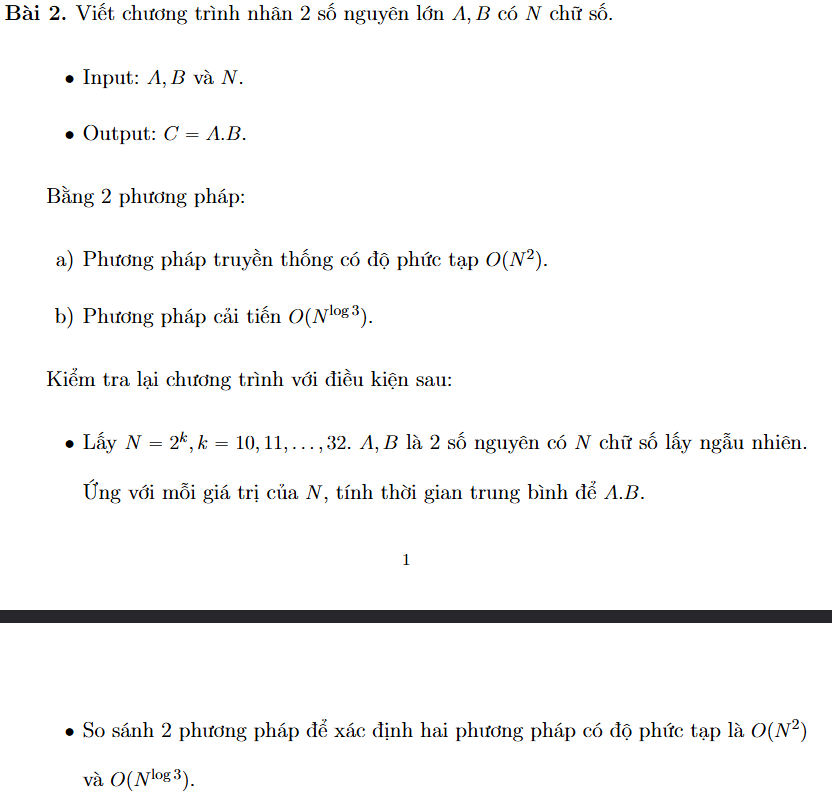

k = 0, took 9.100069291889668e-06s
k = 1, took 7.900060154497623e-06s
k = 2, took 6.700051017105579e-06s
k = 3, took 9.999959729611874e-06s
k = 4, took 2.8499984182417393e-05s
k = 5, took 9.840005077421665e-05s
k = 6, took 0.00037450005766004324s
k = 7, took 0.001554399961605668s
k = 8, took 0.006520400056615472s
k = 9, took 0.04778190003708005s


<>:154: SyntaxWarning: invalid escape sequence '\l'
<>:154: SyntaxWarning: invalid escape sequence '\l'
<>:165: SyntaxWarning: invalid escape sequence '\l'
<>:154: SyntaxWarning: invalid escape sequence '\l'
<>:154: SyntaxWarning: invalid escape sequence '\l'
<>:165: SyntaxWarning: invalid escape sequence '\l'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_12116\3721722924.py:154: SyntaxWarning: invalid escape sequence '\l'
  plot_time_complexity(T_b, bigO_line_b, bigO_label='$O(N^{\log{3}})$',title='So sánh thuật toán câu 2b với $O(N^{\log{3}})$')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_12116\3721722924.py:154: SyntaxWarning: invalid escape sequence '\l'
  plot_time_complexity(T_b, bigO_line_b, bigO_label='$O(N^{\log{3}})$',title='So sánh thuật toán câu 2b với $O(N^{\log{3}})$')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_12116\3721722924.py:165: SyntaxWarning: invalid escape sequence '\l'
  line2, = ax.plot(bigO_line_b, label='$O(N^{\log{3}})$', color='C0', ls='--', alpha=0.8)


k = 10, took 0.12426429998595268s
k = 11, took 0.47576619999017566s
k = 12, took 1.811285899952054s


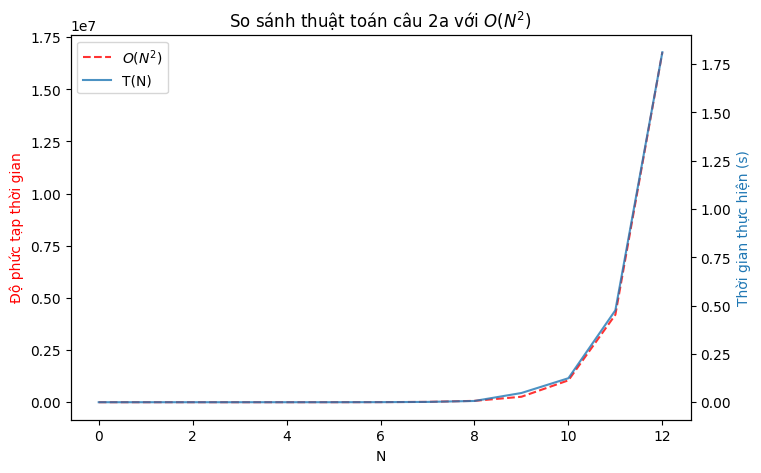

k = 0, took 9.00006853044033e-07s
k = 1, took 4.900037311017513e-06s
k = 2, took 7.2999391704797745e-06s
k = 3, took 1.5199999324977398e-05s
k = 4, took 3.260001540184021e-05s
k = 5, took 8.969998452812433e-05s
k = 6, took 0.00028579996433109045s
k = 7, took 0.0010598000371828675s
k = 8, took 0.0025144999381154776s
k = 9, took 0.007134899962693453s
k = 10, took 0.027131399954669178s
k = 11, took 0.06778169993776828s
k = 12, took 0.21774110000114888s


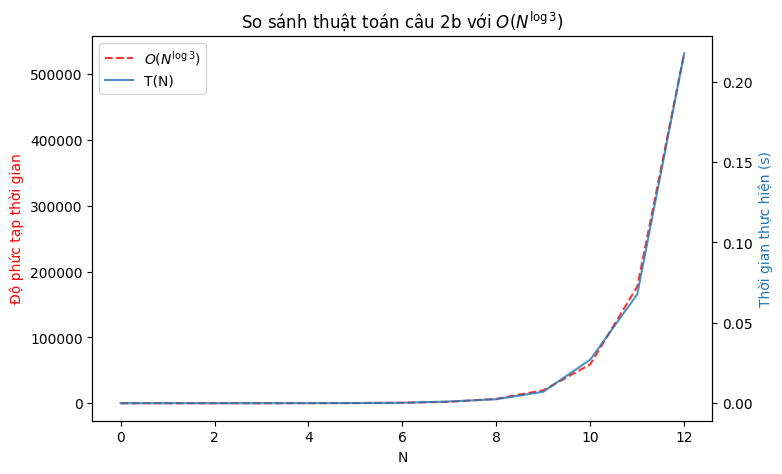

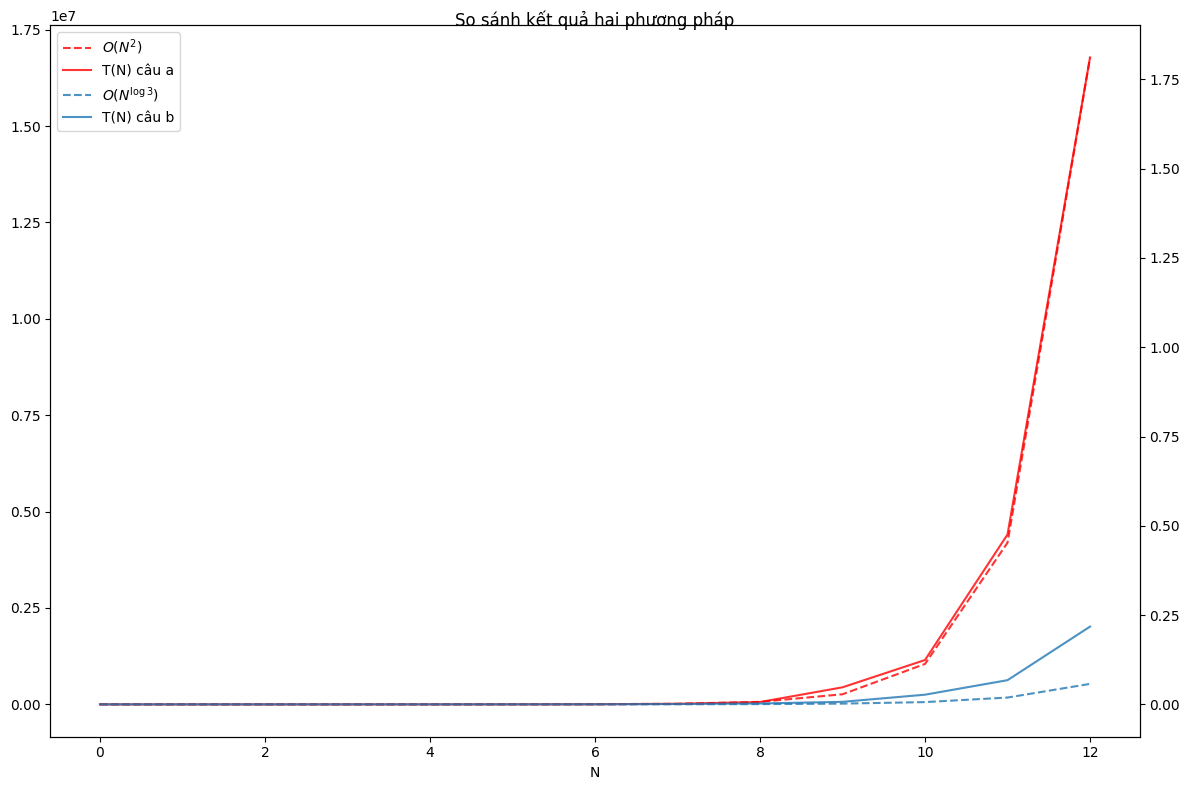

In [16]:
def listRNG(N):
    n = []
    for _ in range(N):
        n.append(random.randint(0, 9))

    # Remove leading zero
    while n[0] == 0:
        n[0] = random.randint(1, 9)
    return n

def to_list(n):
    l = []
    while n:
        l.insert(0, n % 10)
        n //= 10

    return l

def list_to_number(digits):
    number = 0
    for digit in digits:
        number = number * 10 + digit
    return number

# 2a


def classic_multiply(A, B):
    len_a, len_b = len(A), len(B)
    res = [0] * (len_a + len_b)
    
    for i in range(len_a - 1, -1, -1):
        carry = 0
        for j in range(len_b - 1, -1, -1):
            temp = A[i] * B[j] + res[i + j + 1] + carry
            res[i + j + 1] = temp % 10
            carry = temp // 10
        res[i] += carry
        
    while len(res) > 1 and res[0] == 0:
        res.pop(0)
        
    return int("".join(map(str, res)))


T_a = []
Ns_a = []
for k in range(13):
    N = 2 ** k
    Ns_a.append(N)
    A = listRNG(N)
    B = listRNG(N)

    tic = perf_counter()
    classic_multiply(A, B)
    toc = perf_counter()

    duration = toc - tic
    print(f'{k = }, took {duration}s')
    T_a.append(duration)

def plot_time_complexity(T, bigO_line, bigO_label, title=''):

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    ax2 = ax.twinx()
    ax.set_xlabel('N')

    line1, = ax.plot(bigO_line, label=bigO_label, color='r', ls='--', alpha=0.8)
    ax.set_ylabel('Độ phức tạp thời gian', color=line1.get_color())
    line2, = ax2.plot(T, label='T(N)', color='C0', alpha=0.8)
    ax2.set_ylabel('Thời gian thực hiện (s)', color=line2.get_color())
    ax.legend(handles=[line1, line2])

    if title:
        plt.title(title)

    plt.show()
    
    
bigO_line_a = list(map(lambda x: x**2, Ns_a))
plot_time_complexity(T_a, bigO_line_a, bigO_label='$O(N^2)$',title=f'So sánh thuật toán câu 2a với $O(N^2)$')






# 2b
def split(n: int):
    return divmod(n, 10**(numlength(n)//2))

def numlength(n: int):
    l = 0
    while n:
        n //= 10
        l += 1
    return l

def karatsuba_multiply(A, B):
    # Điều kiện dừng đệ quy
    if A < 10 or B < 10:
        return int(A * B)

    # Tìm mốc chia đôi m dựa trên số dài nhất
    str_A, str_B = str(A), str(B)
    n = max(len(str_A), len(str_B))
    m = n // 2
    
    # Lũy thừa để chia cắt số
    power = 10 ** m
    
    # Chia A = A_1 * 10^m + A_2
    A_1, A_2 = divmod(A, power)
    B_1, B_2 = divmod(B, power)
    
    # 3 lệnh gọi đệ quy Karatsuba
    C = karatsuba_multiply(A_1, B_1)          # Tương đương z2
    D = karatsuba_multiply(A_2, B_2)          # Tương đương z0
    E = karatsuba_multiply(A_1 + A_2, B_1 + B_2) - C - D  # Tương đương z1 - z2 - z0
    
    # Gộp lại theo mốc m đã định: C * 10^(2m) + E * 10^m + D
    return (C * (10 ** (2 * m))) + (E * power) + D

def rng(N):
    n = random.randint(0, 9)
    while n == 0:
        n = random.randint(0, 9)

    i = 1
    while i < N:
        n = n*10 + random.randint(0, 9)
        i += 1
    return n


T_b = []
Ns_b = []
for k in range(13):
    N = 2 ** k
    Ns_b.append(N)
    A = rng(N)
    B = rng(N)

    tic = perf_counter()
    karatsuba_multiply(A, B)
    toc = perf_counter()

    duration = toc - tic
    print(f'{k = }, took {duration}s')
    T_b.append(duration)

bigO_line_b = list(map(lambda x: x**log2(3) , Ns_b))
plot_time_complexity(T_b, bigO_line_b, bigO_label='$O(N^{\log{3}})$',title='So sánh thuật toán câu 2b với $O(N^{\log{3}})$')



# So sánh 2 phương pháp
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax2 = ax.twinx()
ax.set_xlabel('N')

line1, = ax.plot(bigO_line_a, label='$O(N^2)$', color='r', ls='--', alpha=0.8)
line2, = ax.plot(bigO_line_b, label='$O(N^{\log{3}})$', color='C0', ls='--', alpha=0.8)
line3, = ax2.plot(T_a, label='T(N) câu a', color='r', alpha=0.8)
line4, = ax2.plot(T_b, label='T(N) câu b', color='C0', alpha=0.8)

ax2.xaxis.set_visible(False)
ax.legend(handles=[line1, line3, line2, line4])

plt.tight_layout()
plt.suptitle(f'So sánh kết quả hai phương pháp')
plt.show()